In [1]:
from monai_model import DDPMPL
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from datetime import datetime
import pytorch_lightning as pl
from PIL import Image


device = torch.device("cuda:2")

The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling t

In [2]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [item for item in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,item))]
        self.image_paths = []
        self.labels = []
        
        # Collect image file paths and corresponding labels
        for label in self.classes:
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(self.classes.index(label))  # Assign numeric labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")  # Load the image
        # image = image.float() / 255.0

        if self.transform:
            image = self.transform(image)

        label = int(self.labels[idx])       # Get the label
        

        
        return image, label

# Data preparation
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize

])
# Specify the path to your dataset
root_dir = '/mnt/raid/home/ajarry/data/trainer'
train_dir = os.path.join(root_dir,"temp_train")
val_dir = os.path.join(root_dir,"temp_val")
# data_dir = '/mnt/famli_netapp_shared/C1_ML_Analysis/famli_ml_lists/AnalysisLists/East/datasets'
# train_dir = os.path.join(data_dir, 'frame_C2_bfly_Head_ordinal_boundary/train/')
# val_dir =  os.path.join(root_dir,"temp_train")

train_dataset = CustomImageDataset(root_dir=train_dir, transform=transform)
val_dataset = CustomImageDataset(root_dir=val_dir, transform=transform)


In [4]:

# Dataloader (you can mess with batch size)
batch_size = 32
num_workers = 4
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=False)

# Define hyperparameters
hparams = {
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'num_train_timesteps': 1000,
    'in_channels': 3,
    'out_channels': 3,
    'use_pre_trained': False
}

model = DDPMPL(**hparams)
model.to(device)

# Set up the trainer
trainer = pl.Trainer(max_epochs=5, precision=16, enable_progress_bar=True)

# Train the model
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | DiffusionModelUNet | 18.5 M | train
1 | scheduler | DDPMScheduler      | 0      | train
---------------------------------------------------------
18.5 M    Trainable params
0         Non-trainable params
18.5 M    Total params
74.022    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB (GPU 0; 79.21 GiB total capacity; 18.83 GiB already allocated; 256.12 MiB free; 19.00 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

: 

In [13]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"outputs_monai/output_{timestamp}/"
os.makedirs(output_dir, exist_ok=True)

final_model_path = os.path.join(output_dir, "model.pth")
torch.save(model.state_dict(), final_model_path)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..-0.103117555].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.85663605].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.560505].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.6678925].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.74345624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.9740402].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range 

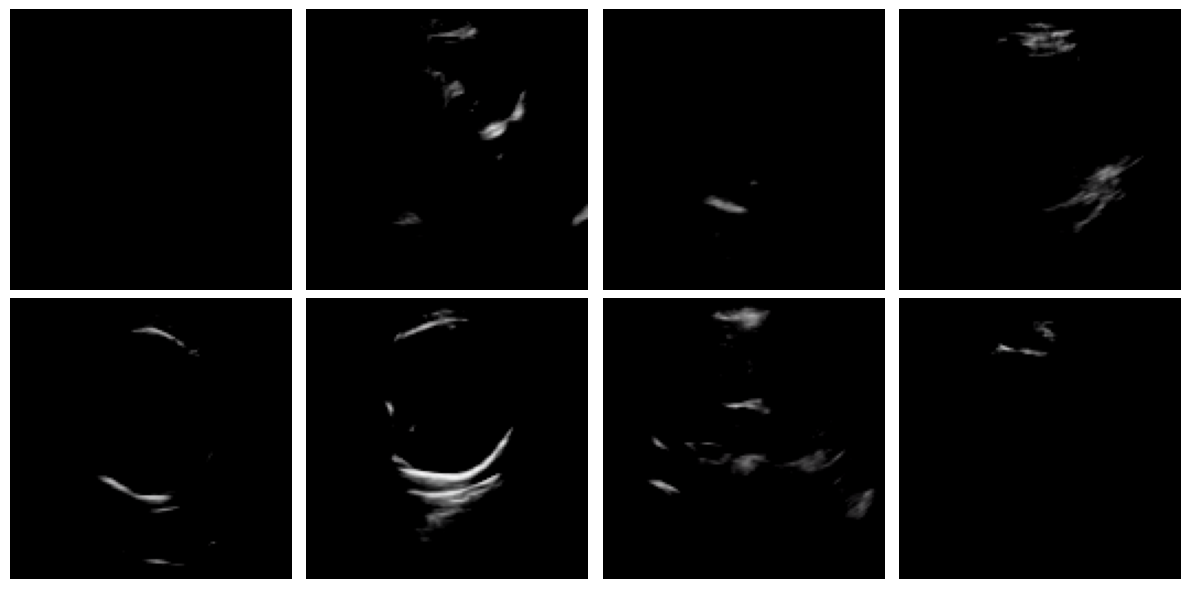

In [14]:
# Generate a sample
model.load_state_dict(torch.load("/mnt/raid/home/ajarry/data/outputs_monai/output_20241210_003358/model.pth"))
model = model.to(device)
shape = (1, 3, 128, 128)  # Adjust based on model's requirements
# List to store generated samples
samples = []

# Generate 8 samples
model.eval()
with torch.no_grad():
    for _ in range(8):
        # Generate a random sample
        noise = torch.randn(shape).to(model.device)  # Noise input
        sample = model(noise).cpu().squeeze()  # Generate image and move to CPU
        samples.append(sample)

# Plot the 8 samples in a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # Transpose the sample to (H, W, C) and convert to numpy for plotting
    img = samples[i].numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()